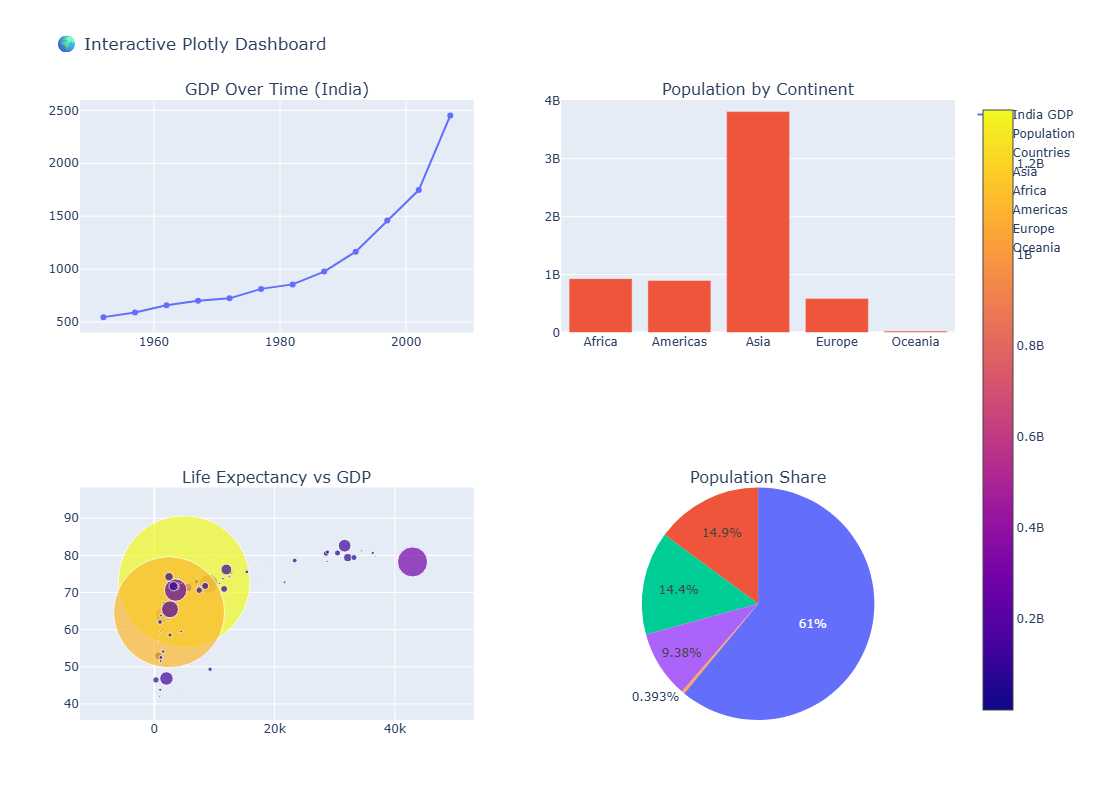

In [1]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Load dataset
df = px.data.gapminder()
df_2007 = df[df['year'] == 2007]

# DEFINE subplot types properly
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("GDP Over Time (India)", "Population by Continent",
                    "Life Expectancy vs GDP", "Population Share"),
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "domain"}]]  # 
)

# 1. Line Chart
india = df[df['country'] == 'India']
fig.add_trace(
    go.Scatter(x=india['year'], y=india['gdpPercap'],
               mode='lines+markers', name='India GDP'),
    row=1, col=1
)

# 2. Bar Chart
bar_data = df_2007.groupby('continent')['pop'].sum().reset_index()
fig.add_trace(
    go.Bar(x=bar_data['continent'], y=bar_data['pop'],
           name='Population'),
    row=1, col=2
)

# 3. Scatter Plot (Bubble)
fig.add_trace(
    go.Scatter(
        x=df_2007['gdpPercap'],
        y=df_2007['lifeExp'],
        mode='markers',
        marker=dict(
            size=df_2007['pop'] / 1e7,
            color=df_2007['pop'],
            showscale=True
        ),
        text=df_2007['country'],
        name='Countries'
    ),
    row=2, col=1
)

# 4. Pie Chart (NOW WORKS)
fig.add_trace(
    go.Pie(
        labels=bar_data['continent'],
        values=bar_data['pop'],
        name='Population Share'
    ),
    row=2, col=2
)

# Layout
fig.update_layout(
    title="🌍 Interactive Plotly Dashboard",
    height=800
)

fig.show()